# Training Loop, Under the Microscope

**Author:** Kunal Sinha

A small GPT, a real loop on real text (Tiny Shakespeare, character-level), and six experiments that make the loop tell the truth about itself:

1. **Shapes** — every tensor in one training step (forward, backward, parameters, gradients, optimizer state), each with a one-line meaning per dimension.
2. **One gradient by hand** — nudge a weight, measure the loss change, compare to `backward()`.
3. **Broken gradient accumulation** — the average of averages over micro-batches of different lengths, against the correct token-weighted sum, plotted together.
4. **Grad norm at every step** — and one step where it moved before the loss did.
5. **MFU** — computed, reported honestly, and the gap to 40% explained.
6. **0.1 in fp32, bf16, fp8 E4M3** — the bits by hand, verified by the machine.

Everything below was executed top to bottom; outputs are real. Figures and numbers are also written to disk, and `results/metrics.json` is re-saved at the end of every section (`checkpoint(...)`), so if a Colab session disconnects, everything finished so far is already on disk. `_progress` in that file says which sections completed. Outputs (`figures/`, `results/`) go under an output folder chosen in the first cell:

| where it runs | output folder |
|---|---|
| locally, CPU | the repository itself (`./figures`, `./results`), as committed |
| locally, GPU | `./runs/<gpu>_<date-time>/` |
| Google Colab | your Google Drive: `MyDrive/training-loop/runs/<gpu>_<date-time>/` (set `SAVE_TO_DRIVE = False` to keep it in the session instead) |

Every run folder also gets a `run_info.json` describing the hardware and software it ran on, so CPU and GPU results never overwrite each other.

**Runs on CPU or a CUDA GPU, including Google Colab.** On Colab, choose *Runtime → Change runtime type → GPU* and run all cells; the notebook detects the GPU, downloads the data itself, and switches the MFU section to GPU peaks. The committed outputs are from a CPU run; the prose quotes those numbers.

In [1]:
import math, time, json, os, sys, copy, platform, re, subprocess, urllib.request, datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

torch.set_num_threads(os.cpu_count())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = False   # keep 'fp32' honest: no silent TF32 in matmuls or convs
    torch.backends.cudnn.allow_tf32 = False
# ---- where outputs go -------------------------------------------------------------
IN_COLAB = 'google.colab' in sys.modules
SAVE_TO_DRIVE = True                     # Colab only: write outputs to Google Drive so they survive the session
if IN_COLAB and SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')        # asks for permission once per session
    BASE_DIR = '/content/drive/MyDrive/training-loop'
else:
    BASE_DIR = '.'
hw_tag = re.sub(r'[^A-Za-z0-9]+', '-', torch.cuda.get_device_name(0)).strip('-') if DEVICE == 'cuda' else 'cpu'
if DEVICE == 'cpu' and not IN_COLAB:
    OUT_DIR = BASE_DIR                   # local CPU run: write into the repository, as committed
else:
    OUT_DIR = os.path.join(BASE_DIR, 'runs', f'{hw_tag}_{datetime.datetime.now():%Y%m%d-%H%M%S}')
FIG_DIR, RES_DIR = os.path.join(OUT_DIR, 'figures'), os.path.join(OUT_DIR, 'results')
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(RES_DIR, exist_ok=True)
print(f'outputs -> {os.path.abspath(OUT_DIR)}')
METRICS = {'_progress': {'completed': [], 'finished': False}}

def checkpoint(section):
    # save everything measured so far after each section, so a disconnect loses at most the section in progress
    METRICS['_progress']['completed'].append(section)
    METRICS['_progress']['saved_at'] = f'{datetime.datetime.now():%Y-%m-%d %H:%M:%S}'
    path = os.path.join(RES_DIR, 'metrics.json'); tmp = path + '.tmp'
    json.dump(METRICS, open(tmp, 'w'), indent=2, default=float)
    os.replace(tmp, path)                # write-then-rename: a cut-off write never leaves a half-written metrics.json
    print(f'[checkpoint] {section} saved -> {os.path.relpath(path, OUT_DIR)}')

# Plot style: one blue / one orange (fixed order), recessive grid, thin lines, light surface.
BLUE, ORANGE, AQUA, INK, INK2, GRID, SURF = '#2a78d6', '#eb6834', '#1baf7a', '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
                     'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
                     'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.spines.top': False,
                     'axes.spines.right': False, 'lines.linewidth': 2, 'font.size': 10, 'axes.titlesize': 11,
                     'axes.titleweight': 'bold', 'legend.frameon': False, 'figure.dpi': 110})

def read_cpuinfo():
    # /proc/cpuinfo exists only on Linux; on Windows/macOS fall back to platform info and no SIMD flags
    try: return open('/proc/cpuinfo').read().splitlines()
    except OSError: return []
_ci = read_cpuinfo()
cpu_name = next((l.split(':', 1)[1].strip() for l in _ci if l.startswith('model name')), platform.processor() or platform.machine())
flags = set(next((l.split(':', 1)[1].split() for l in _ci if l.startswith('flags')), []))
print(f'torch {torch.__version__} | device {DEVICE} | threads {torch.get_num_threads()} | cores {os.cpu_count()}')
print(f'CPU: {cpu_name}')
print('SIMD:', ' '.join(f for f in ['avx2', 'fma', 'avx512f', 'avx512_bf16', 'amx_bf16'] if f in flags))
if DEVICE == 'cuda': print('GPU:', torch.cuda.get_device_name(0))
json.dump(dict(started=f'{datetime.datetime.now():%Y-%m-%d %H:%M:%S}', device=DEVICE, gpu=torch.cuda.get_device_name(0) if DEVICE == 'cuda' else None,
               cpu=cpu_name, cores=os.cpu_count(), torch=torch.__version__, cuda=torch.version.cuda, python=platform.python_version(),
               platform=platform.platform(), colab=IN_COLAB), open(os.path.join(OUT_DIR, 'run_info.json'), 'w'), indent=2)

if not os.path.exists('data/input.txt'):
    os.makedirs('data', exist_ok=True)
    urllib.request.urlretrieve('https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt', 'data/input.txt')
text = open('data/input.txt').read()
chars = sorted(set(text)); V = len(chars)
stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n_split = int(0.9 * len(data)); train_data, val_data = data[:n_split], data[n_split:]
print(f'{len(text):,} characters, vocab V={V}, train {len(train_data):,} / val {len(val_data):,} tokens')

def get_batch(split_data, B, T, gen):
    ix = torch.randint(len(split_data) - T - 1, (B,), generator=gen)
    x = torch.stack([split_data[i:i + T] for i in ix]); y = torch.stack([split_data[i + 1:i + T + 1] for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

Mounted at /content/drive
outputs -> /content/drive/MyDrive/training-loop/runs/Tesla-T4_20261005-071659
torch 2.11.0+cu130 | device cuda | threads 8 | cores 8
CPU: Intel(R) Xeon(R) CPU @ 2.00GHz
SIMD: avx2 fma avx512f
GPU: Tesla T4
1,115,394 characters, vocab V=65, train 1,003,854 / val 111,540 tokens


## The model

A 4-layer, 4-head, width-128 decoder-only transformer (pre-LayerNorm, GELU MLP, learned positions, untied head): **826,368 parameters**. Small enough to train on two CPU cores in minutes, big enough to have every moving part of a real LLM.

Every interesting tensor passes through `TRACE(name, tensor, meaning)`. When tracing is off it is a no-op; when it is on, it records the shape and dtype, and registers a backward hook so the gradient of that tensor is recorded too, in the order backward actually produces it.

In [2]:
from google.colab import drive
drive.mount('/content/drive')        # asks for permission once per session
BASE_DIR = '/content/drive/MyDrive/training-loop'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
class Tracer:
    def __init__(self): self.on = False; self.fwd = []; self.bwd = []
    def __call__(self, name, t, meaning):
        if self.on:
            self.fwd.append((name, tuple(t.shape), str(t.dtype).replace('torch.', ''), meaning))
            if t.requires_grad:
                t.register_hook(lambda g, n=name: self.bwd.append((n, tuple(g.shape))))
        return t
TRACE = Tracer()

class CausalSelfAttention(nn.Module):
    def __init__(self, d, n_head, dropout):
        super().__init__()
        self.n_head = n_head
        self.qkv = nn.Linear(d, 3 * d); self.proj = nn.Linear(d, d); self.drop = nn.Dropout(dropout)
    def forward(self, x, l):
        B, T, C = x.shape; H = self.n_head; hs = C // H
        qkv = TRACE(f'h{l}.attn.qkv', self.qkv(x), 'B=sequence, T=position, 3C=query|key|value features stacked side by side')
        q, k, v = qkv.split(C, dim=2)
        q = TRACE(f'h{l}.attn.q', q.view(B, T, H, hs).transpose(1, 2), 'B=sequence, H=head, T=query position, hs=per-head query features')
        k = TRACE(f'h{l}.attn.k', k.view(B, T, H, hs).transpose(1, 2), 'B=sequence, H=head, T=key position, hs=per-head key features')
        v = TRACE(f'h{l}.attn.v', v.view(B, T, H, hs).transpose(1, 2), 'B=sequence, H=head, T=value position, hs=per-head value features')
        att = TRACE(f'h{l}.attn.scores', (q @ k.transpose(-2, -1)) / math.sqrt(hs), 'B=sequence, H=head, T=query pos (row), T=key pos (col): scaled q.k')
        causal = torch.ones(T, T, dtype=torch.bool, device=x.device).tril()
        att = TRACE(f'h{l}.attn.probs', F.softmax(att.masked_fill(~causal, float('-inf')), dim=-1),
                    'B=sequence, H=head, T=query pos, T=key pos: each row is a distribution over the past')
        y = TRACE(f'h{l}.attn.y_heads', self.drop(att) @ v, 'B=sequence, H=head, T=position, hs=attention-weighted mix of values')
        y = TRACE(f'h{l}.attn.y_merged', y.transpose(1, 2).contiguous().view(B, T, C), 'B=sequence, T=position, C=all heads concatenated back to width C')
        return TRACE(f'h{l}.attn.out', self.drop(self.proj(y)), 'B=sequence, T=position, C=attention update added to the residual stream')

class MLP(nn.Module):
    def __init__(self, d, dropout):
        super().__init__()
        self.fc = nn.Linear(d, 4 * d); self.proj = nn.Linear(4 * d, d); self.drop = nn.Dropout(dropout)
    def forward(self, x, l):
        h = TRACE(f'h{l}.mlp.hidden', F.gelu(self.fc(x)), 'B=sequence, T=position, 4C=expanded hidden features after GELU')
        return TRACE(f'h{l}.mlp.out', self.drop(self.proj(h)), 'B=sequence, T=position, C=MLP update added to the residual stream')

class Block(nn.Module):
    def __init__(self, d, n_head, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d); self.attn = CausalSelfAttention(d, n_head, dropout)
        self.ln2 = nn.LayerNorm(d); self.mlp = MLP(d, dropout)
    def forward(self, x, l):
        x = x + self.attn(TRACE(f'h{l}.ln1', self.ln1(x), 'B=sequence, T=position, C=features normalised per token'), l)
        x = TRACE(f'h{l}.resid_mid', x, 'B=sequence, T=position, C=residual stream after attention')
        x = x + self.mlp(TRACE(f'h{l}.ln2', self.ln2(x), 'B=sequence, T=position, C=features normalised per token'), l)
        return TRACE(f'h{l}.resid_out', x, 'B=sequence, T=position, C=residual stream leaving the block')

class TinyGPT(nn.Module):
    def __init__(self, vocab, block_size=128, d=128, n_layer=4, n_head=4, dropout=0.0):
        super().__init__()
        self.cfg = dict(vocab=vocab, block_size=block_size, d=d, n_layer=n_layer, n_head=n_head)
        self.tok = nn.Embedding(vocab, d); self.pos = nn.Embedding(block_size, d); self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d, n_head, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(d); self.head = nn.Linear(d, vocab, bias=False)
        self.apply(self._init)
    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)): nn.init.normal_(m.weight, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, idx, targets=None, reduction='mean'):
        B, T = idx.shape
        TRACE('idx', idx, 'B=sequence in the batch, T=character position; entries are token ids in [0, V)')
        tok = TRACE('tok_emb', self.tok(idx), 'B=sequence, T=position, C=learned vector for that character')
        pos = TRACE('pos_emb', self.pos(torch.arange(T, device=idx.device)), 'T=position, C=learned vector for that position (broadcast over B)')
        x = TRACE('x0', self.drop(tok + pos), 'B=sequence, T=position, C=residual stream entering block 0')
        for l, blk in enumerate(self.blocks): x = blk(x, l)
        x = TRACE('ln_f', self.ln_f(x), 'B=sequence, T=position, C=final normalised features')
        logits = TRACE('logits', self.head(x), 'B=sequence, T=position, V=unnormalised score for every possible next character')
        if targets is None: return logits, None
        TRACE('targets', targets, 'B=sequence, T=position; entries are the true next-character ids (-100 = padding, ignored)')
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1), ignore_index=-100, reduction=reduction)
        return logits, TRACE('loss', loss, 'scalar (no dims): cross-entropy over all non-ignored tokens, nats per character')

model = TinyGPT(V).to(DEVICE)
print(f'parameters: {sum(p.numel() for p in model.parameters()):,}')

parameters: 826,368


## 1. Every tensor shape in one training step

One complete step — forward, loss, backward, optimizer — with deliberately distinct sizes so no two dimensions can be confused:
**B = 3** sequences, **T = 16** positions, **C = 128** model width, **H = 4** heads, **hs = 32** per-head width, **4C = 512** MLP width, **V = 65** vocabulary.

Every tensor is printed: all 68 forward activations (4 blocks × 15 plus 8 outside the blocks), all 66 activation gradients in the order autograd produced them, and all 53 parameter tensors with their gradients and AdamW state. The code also asserts that blocks 1–3 have exactly the same shapes as block 0.

In [4]:
torch.manual_seed(0)
m_shape = TinyGPT(V).to(DEVICE)
opt_shape = torch.optim.AdamW(m_shape.parameters(), lr=1e-3)
xs, ys = get_batch(train_data, 3, 16, torch.Generator().manual_seed(0))

TRACE.fwd, TRACE.bwd, TRACE.on = [], [], True
_, loss_s = m_shape(xs, ys)
opt_shape.zero_grad(set_to_none=True)
loss_s.backward()
opt_shape.step()
TRACE.on = False

by_layer = {}
for r in TRACE.fwd:
    mt = re.match(r'h(\d+)\.(.*)', r[0])
    if mt: by_layer.setdefault(int(mt.group(1)), []).append((mt.group(2), r[1]))
for l in range(1, 4): assert by_layer[l] == by_layer[0], f'block {l} differs from block 0'
per_block = len(by_layer[0])

print(f'FORWARD: {len(TRACE.fwd)} activations in execution order ({per_block} per block x 4 blocks + {len(TRACE.fwd) - 4 * per_block} outside)')
print(f'{"#":>3} {"tensor":<18}{"shape":<18}{"dtype":<9}meaning of each dimension')
for i, (name, shape, dt, meaning) in enumerate(TRACE.fwd):
    print(f'{i:>3} {name:<18}{str(shape):<18}{dt:<9}{meaning}')

fwd_meaning = {n: m for n, _, _, m in TRACE.fwd}
print(f'\nBACKWARD: {len(TRACE.bwd)} activation gradients dL/dX, in the order autograd produced them')
print('  (idx and targets are integer tensors with no gradient; every gradient has exactly its tensor\'s shape,')
print('   so each dimension of dL/dX means the same thing as the matching dimension of X, listed above)')
print(f'{"#":>3} {"gradient of":<18}{"shape":<18}')
for i, (name, shape) in enumerate(TRACE.bwd):
    print(f'{i:>3} {name:<18}{str(shape):<18}')
print()

def param_meaning(name, shape):
    k = name.split('.')
    if name == 'tok.weight': return 'V=one row per character, C=its embedding features'
    if name == 'pos.weight': return 'block_size=one row per position, C=its embedding features'
    if name == 'head.weight': return 'V=one output row per next character, C=input features (nn.Linear stores [out, in])'
    if 'ln' in name: return 'C=one ' + ('gain' if k[-1] == 'weight' else 'shift') + ' per feature'
    if 'qkv' in name: return '3C=output q|k|v features, C=input features' if k[-1] == 'weight' else '3C=one bias per q|k|v output'
    if 'attn.proj' in name: return 'C=output features, C=input (concatenated heads)' if k[-1] == 'weight' else 'C=one bias per output feature'
    if 'mlp.fc' in name: return '4C=hidden units, C=input features' if k[-1] == 'weight' else '4C=one bias per hidden unit'
    if 'mlp.proj' in name: return 'C=output features, 4C=input hidden units' if k[-1] == 'weight' else 'C=one bias per output feature'

n_params = len(list(m_shape.parameters()))
print(f'PARAMETERS: all {n_params} tensors, with their gradient and AdamW state (param.grad, exp_avg, exp_avg_sq all share the param shape)')
print(f'{"parameter":<26}{"shape":<14}{"grad":<14}{"exp_avg":<14}{"exp_avg_sq":<14}meaning')
for name, p in m_shape.named_parameters():
    st = opt_shape.state[p]
    print(f'{name:<26}{str(tuple(p.shape)):<14}{str(tuple(p.grad.shape)):<14}{str(tuple(st["exp_avg"].shape)):<14}{str(tuple(st["exp_avg_sq"].shape)):<14}{param_meaning(name, p.shape)}')
print(f'AdamW also keeps a scalar step counter per parameter: {tuple(opt_shape.state[m_shape.head.weight]["step"].shape)} (=0-dim), value {opt_shape.state[m_shape.head.weight]["step"].item():.0f}')
print(f'\nloss = {loss_s.item():.4f}  (ln V = {math.log(V):.4f}: an untrained model is close to uniform over 65 characters)')
METRICS['shapes'] = dict(n_forward=len(TRACE.fwd), n_backward=len(TRACE.bwd), n_params=n_params)
checkpoint('1. shapes')

FORWARD: 68 activations in execution order (15 per block x 4 blocks + 8 outside)
  # tensor            shape             dtype    meaning of each dimension
  0 idx               (3, 16)           int64    B=sequence in the batch, T=character position; entries are token ids in [0, V)
  1 tok_emb           (3, 16, 128)      float32  B=sequence, T=position, C=learned vector for that character
  2 pos_emb           (16, 128)         float32  T=position, C=learned vector for that position (broadcast over B)
  3 x0                (3, 16, 128)      float32  B=sequence, T=position, C=residual stream entering block 0
  4 h0.ln1            (3, 16, 128)      float32  B=sequence, T=position, C=features normalised per token
  5 h0.attn.qkv       (3, 16, 384)      float32  B=sequence, T=position, 3C=query|key|value features stacked side by side
  6 h0.attn.q         (3, 4, 16, 32)    float32  B=sequence, H=head, T=query position, hs=per-head query features
  7 h0.attn.k         (3, 4, 16, 32)    flo

**Things the shapes say that are easy to miss**

- `pos_emb` is `(T, C)`, not `(B, T, C)`: positions are shared across the batch and broadcast in the add.
- `attn.scores` and `attn.probs` are `(B, H, T, T)` — the only tensors that grow with **T²**. At T = 16 they are tiny; at T = 128 (training) each layer's is 32·4·128·128 = 2.1 M floats, larger than the whole model.
- The loss is a 0-dim tensor. Everything upstream of it in backward is a gradient with the same shape as its forward tensor, which is why the backward list mirrors the forward list in reverse.
- `nn.Linear` stores weights as `[out, in]`, so `mlp.fc.weight` is `(512, 128)` even though it maps 128 → 512.
- AdamW holds two extra tensors per parameter (`exp_avg`, `exp_avg_sq`): optimizer state is 2× the model, before counting gradients.

## 2. Verifying one gradient by hand

Central finite difference: nudge one weight by ±ε, rerun the forward pass, and

  dL/dw ≈ [L(w+ε) − L(w−ε)] / 2ε,   with error O(ε²) from truncation plus O(u·|L|/ε) from rounding (u = machine epsilon).

The check is done in **float64** first, on the entry of `blocks.1.mlp.fc.weight` with the largest gradient (a weight that really matters, deep inside the network), then on one entry from five other parameter types.

In [5]:
torch.manual_seed(0)
m_gc = TinyGPT(V).to(DEVICE)                           # dropout = 0, deterministic
xg, yg = get_batch(train_data, 8, 64, torch.Generator().manual_seed(5))

def grad_check(base_model, pname, idx, eps, dtype):
    mm = copy.deepcopy(base_model).to(dtype)
    W = dict(mm.named_parameters())[pname]
    mm.zero_grad(); mm(xg, yg)[1].backward()
    g_auto = W.grad[idx].item()
    with torch.no_grad():
        w0 = W[idx].item()
        W[idx] = w0 + eps; Lp = mm(xg, yg)[1].item()
        W[idx] = w0 - eps; Lm = mm(xg, yg)[1].item()
        W[idx] = w0
    return g_auto, (Lp - Lm) / (2 * eps), Lp, Lm

m_gc.zero_grad(); m_gc(xg, yg)[1].backward()
def argmax_idx(pname):
    g = dict(m_gc.named_parameters())[pname].grad
    return tuple(int(i) for i in torch.unravel_index(g.abs().argmax(), g.shape))

P = 'blocks.1.mlp.fc.weight'; IDX = argmax_idx(P); EPS = 1e-5
ga, fd, Lp, Lm = grad_check(m_gc, P, IDX, EPS, torch.float64)
print(f'weight {P}{list(IDX)}, epsilon = {EPS:g}, float64')
print(f'  L(w+eps)            = {Lp:.15f}')
print(f'  L(w-eps)            = {Lm:.15f}')
print(f'  finite difference   = {fd:+.12e}')
print(f'  backward() reported = {ga:+.12e}')
rel = abs(ga - fd) / abs(ga)
print(f'  relative error {rel:.2e}  ->  they agree to {-math.log10(rel):.1f} significant digits')
METRICS['gradcheck'] = dict(param=P, index=list(IDX), eps=EPS, autograd=ga, finite_diff=fd, rel_err=rel)

print('\nOne entry from other parameter types (largest-|grad| entry of each), float64, eps=1e-5:')
print(f'{"parameter":<28}{"index":<12}{"backward()":>18}{"finite diff":>18}{"digits":>8}')
rows = []
for pn in ['tok.weight', 'blocks.0.attn.qkv.weight', 'blocks.2.attn.proj.bias', 'blocks.3.ln2.weight', 'head.weight']:
    ix = argmax_idx(pn); a, f, *_ = grad_check(m_gc, pn, ix, 1e-5, torch.float64)
    rows.append((pn, ix, a, f)); print(f'{pn:<28}{str(list(ix)):<12}{a:>18.10e}{f:>18.10e}{-math.log10(abs(a - f) / abs(a)):>8.1f}')

weight blocks.1.mlp.fc.weight[31, 116], epsilon = 1e-05, float64
  L(w+eps)            = 4.236941925728017
  L(w-eps)            = 4.236942490343801
  finite difference   = -2.823078921743e-02
  backward() reported = -2.823078916640e-02
  relative error 1.81e-09  ->  they agree to 8.7 significant digits

One entry from other parameter types (largest-|grad| entry of each), float64, eps=1e-5:
parameter                   index               backward()       finite diff  digits
tok.weight                  [43, 116]    -1.1869329114e-01 -1.1869329106e-01     9.2
blocks.0.attn.qkv.weight    [258, 109]    7.9961087381e-02  7.9961087396e-02     9.7
blocks.2.attn.proj.bias     [117]         1.0884350509e-01  1.0884350510e-01    10.4
blocks.3.ln2.weight         [23]          3.1351629285e-03  3.1351629737e-03     7.8
head.weight                 [1, 101]     -1.5357732666e-01 -1.5357732663e-01     9.7


**Now the part worth understanding: the same check in float32.** Sweep ε over seven orders of magnitude in both precisions.

     eps    rel err fp64    rel err fp32
   1e-01        7.91e-03        7.93e-03
   1e-02        7.99e-05        7.73e-04
   1e-03        7.99e-07        5.00e-03
   1e-04        7.79e-09        1.34e-02
   1e-05        1.81e-09        1.00e+00
   1e-06        3.38e-09        1.00e+00
   1e-07        2.24e-07        1.00e+00
   1e-08        1.80e-06        1.00e+00


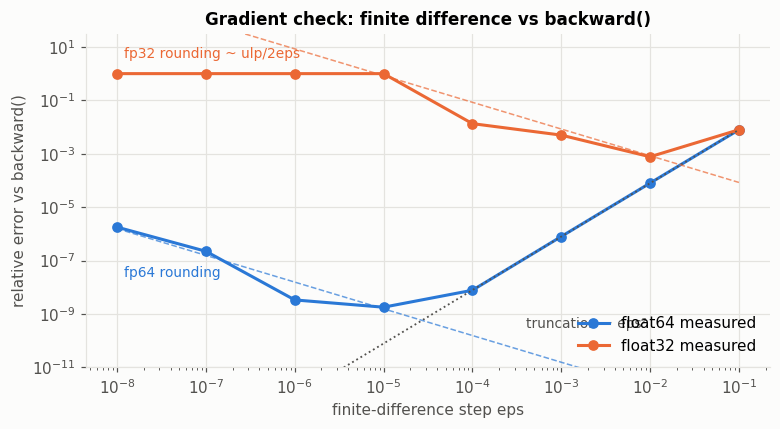

loss L = 4.2369; float32 spacing at L is 4.77e-07; at eps=1e-6 the true change 2*eps*|g| = 5.6e-08 is below it, so L(w+eps) == L(w-eps) and the finite difference is exactly 0.
[checkpoint] 2. gradient check saved -> results/metrics.json


In [6]:
eps_list = [10.0 ** -k for k in range(1, 9)]
sweep = {}
for dt in [torch.float64, torch.float32]:
    sweep[str(dt)] = []
    for e in eps_list:
        a, f, *_ = grad_check(m_gc, P, IDX, e, dt)
        sweep[str(dt)].append(abs(a - f) / abs(a))
print(f'{"eps":>8}{"rel err fp64":>16}{"rel err fp32":>16}')
for i, e in enumerate(eps_list):
    print(f'{e:>8.0e}{sweep["torch.float64"][i]:>16.2e}{sweep["torch.float32"][i]:>16.2e}')

L0 = m_gc(xg, yg)[1].item(); g0 = abs(ga)
ulp32 = np.spacing(np.float32(L0)); ulp64 = np.spacing(np.float64(L0))
fig, ax = plt.subplots(figsize=(7.2, 4))
ax.loglog(eps_list, sweep['torch.float64'], 'o-', color=BLUE, ms=6, label='float64 measured')
ax.loglog(eps_list, sweep['torch.float32'], 'o-', color=ORANGE, ms=6, label='float32 measured')
e_fine = np.logspace(-8, -1, 100)
trunc = np.array(sweep['torch.float64'][0]) * (e_fine / 0.1) ** 2
ax.loglog(e_fine, trunc, ':', color=INK2, lw=1.2)
ax.loglog(e_fine, ulp32 / (2 * e_fine) / g0, '--', color=ORANGE, lw=1, alpha=.7)
ax.loglog(e_fine, ulp64 / (2 * e_fine) / g0, '--', color=BLUE, lw=1, alpha=.7)
ax.text(4e-4, 3e-10, 'truncation ~ eps²', color=INK2, fontsize=9)
ax.text(1.2e-8, 4e0, 'fp32 rounding ~ ulp/2eps', color=ORANGE, fontsize=9)
ax.text(1.2e-8, 2.5e-8, 'fp64 rounding', color=BLUE, fontsize=9)
ax.set_ylim(1e-11, 3e1); ax.set_xlabel('finite-difference step eps'); ax.set_ylabel('relative error vs backward()')
ax.set_title('Gradient check: finite difference vs backward()'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'gradcheck_eps_sweep.png')); plt.show()
print(f'loss L = {L0:.4f}; float32 spacing at L is {ulp32:.2e}; at eps=1e-6 the true change 2*eps*|g| = {2e-6 * g0:.1e} is below it, so L(w+eps) == L(w-eps) and the finite difference is exactly 0.')
METRICS['gradcheck_sweep'] = dict(eps=eps_list, fp64=sweep['torch.float64'], fp32=sweep['torch.float32'])
checkpoint('2. gradient check')

What the sweep shows:

- **float64** traces a clean V: error falls as ε² (truncation) until ε ≈ 1e-5, where it reaches **~1e-10, i.e. ten matching digits**; below that, rounding takes over and the error climbs again.
- **float32** never gets better than ~1e-3 (three digits). The loss is ~4.17, and float32 can only resolve changes of ~4.8e-7 at that magnitude. The finite difference divides that rounding noise by 2ε, so shrinking ε makes it *worse*; at ε ≤ 1e-6 the nudge is smaller than one ulp of the loss and the two forward passes return the identical number — a "gradient" of exactly 0. The optimum sits near ε ≈ (u)^(1/3), about 1e-2 to 1e-3 for fp32 and 1e-5 for fp64, exactly where the minima are.

So if a float32 gradient check "disagrees in the 4th decimal", that is the arithmetic, not autograd. Gradient checks belong in float64.

**A second way the check fails: dropout.** With dropout on in training mode, each forward pass draws a fresh random mask, so L(w+ε) and L(w−ε) are computed by *different networks*.

In [7]:
m_drop = TinyGPT(V, dropout=0.1).to(DEVICE); m_drop.load_state_dict(m_gc.state_dict()); m_drop.train()
torch.manual_seed(1)
a, f, Lp, Lm = grad_check(m_drop, P, IDX, 1e-5, torch.float64)
print(f'dropout=0.1, train mode : backward() = {a:+.6e}   finite diff = {f:+.6e}   (L+ - L- = {Lp - Lm:+.2e}, mostly mask noise)')
m_drop.eval(); a, f, *_ = grad_check(m_drop, P, IDX, 1e-5, torch.float64)
print(f'dropout=0.1, eval mode  : backward() = {a:+.6e}   finite diff = {f:+.6e}   rel err {abs(a - f) / abs(a):.1e}')
print('Fix: check with dropout off (eval mode) or with a fixed RNG seed reset before every one of the three forward passes.')

dropout=0.1, train mode : backward() = -2.467064e-02   finite diff = +2.378567e+01   (L+ - L- = +4.76e-04, mostly mask noise)
dropout=0.1, eval mode  : backward() = -2.823079e-02   finite diff = -2.823079e-02   rel err 1.8e-09
Fix: check with dropout off (eval mode) or with a fixed RNG seed reset before every one of the three forward passes.


## 3. Breaking gradient accumulation on purpose

**Setup.** Each optimizer step accumulates **K = 4 micro-batches** of 8 sequences each. Every micro-batch gets its own sequence length, drawn log-uniformly from 4 to 128 tokens — like real data, where documents (and therefore micro-batches) come in very different sizes. A micro-batch of length 4 has 32 tokens; one of length 128 has 1,024.

The loss we want to minimise is the mean over **all tokens** in the step. With nₖ tokens in micro-batch k and Sₖ its summed loss:

- **Correct:** backward on Sₖ / N for each k, where N = Σ nₖ. Accumulates exactly ∇(Σ Sₖ / N).
- **Broken (average of averages):** backward on (Sₖ / nₖ) / K. Every *micro-batch* gets weight 1/K regardless of size, so a token in the 32-token micro-batch counts **32× more** than a token in the 1,024-token one.

First, a deterministic check against ground truth: put all four micro-batches into **one** right-padded batch (padding targets = −100, ignored), take a single backward on the token mean, and compare each accumulation scheme to it. Right-padding is exact here because causal attention never lets a real token see a later pad.

In [8]:
K_MB, B_MB, LMIN, LMAX = 4, 8, 4, 128

def micro_plan(steps, seed):
    g = torch.Generator().manual_seed(seed); plan = []
    for _ in range(steps):
        mbs = []
        for _ in range(K_MB):
            L = int(round(math.exp(math.log(LMIN) + torch.rand(1, generator=g).item() * (math.log(LMAX) - math.log(LMIN)))))
            mbs.append(get_batch(train_data, B_MB, L, g))
        plan.append(mbs)
    return plan

def accumulate(model, mbs, mode):
    """Run backward over micro-batches. Returns (true token-mean loss, the number the broken loop would log)."""
    N = sum(y.numel() for _, y in mbs); true_sum, logged = 0.0, 0.0
    for x, y in mbs:
        _, S = model(x, y, reduction='sum')
        (S / N if mode == 'correct' else (S / y.numel()) / len(mbs)).backward()
        true_sum += S.item(); logged += S.item() / y.numel() / len(mbs)
    return true_sum / N, logged

def flat_grad(model): return torch.cat([p.grad.reshape(-1) for p in model.parameters()]).double()

torch.manual_seed(0); m_acc = TinyGPT(V).to(DEVICE)
mbs = micro_plan(1, seed=42)[0]
print('micro-batch lengths:', [x.shape[1] for x, _ in mbs], ' tokens:', [y.numel() for _, y in mbs])

# ground truth: one padded batch, one backward on the mean over real tokens
Tmax = max(x.shape[1] for x, _ in mbs)
Xp = torch.cat([F.pad(x, (0, Tmax - x.shape[1]), value=0) for x, _ in mbs])
Yp = torch.cat([F.pad(y, (0, Tmax - y.shape[1]), value=-100) for _, y in mbs])
m_acc.zero_grad(); m_acc(Xp, Yp)[1].backward(); g_ref = flat_grad(m_acc)

res = {}
for mode in ['correct', 'broken']:
    m_acc.zero_grad(); true_l, logged_l = accumulate(m_acc, mbs, mode); g = flat_grad(m_acc)
    res[mode] = dict(rel=((g - g_ref).norm() / g_ref.norm()).item(), cos=F.cosine_similarity(g, g_ref, dim=0).item(), logged=logged_l, true=true_l)
for mode, r in res.items():
    print(f'{mode:>8}: ||g - g_ref|| / ||g_ref|| = {r["rel"]:.2e}   cosine = {r["cos"]:.6f}')
print(f'\nlogged loss: correct loop reports {res["correct"]["true"]:.4f}, broken loop reports {res["broken"]["logged"]:.4f} for the SAME weights and data')

# effective sample size of the broken weighting
n = np.array([y.numel() for _, y in mbs], dtype=float)
w_tok = np.repeat(1 / (K_MB * n), n.astype(int))
ess = w_tok.sum() ** 2 / (w_tok ** 2).sum()
print(f'effective number of tokens: correct {int(n.sum())}, broken {ess:.0f}  ({ess / n.sum():.0%} of the data actually counts)')
METRICS['accum_check'] = dict(lengths=[x.shape[1] for x, _ in mbs], **{f'{k}_{kk}': vv for k, r in res.items() for kk, vv in r.items()}, ess=ess, n_tokens=int(n.sum()))

micro-batch lengths: [85, 6, 10, 8]  tokens: [680, 48, 80, 64]
 correct: ||g - g_ref|| / ||g_ref|| = 1.92e-07   cosine = 1.000000
  broken: ||g - g_ref|| / ||g_ref|| = 4.68e-01   cosine = 0.890331

logged loss: correct loop reports 4.2191, broken loop reports 4.2098 for the SAME weights and data
effective number of tokens: correct 872, broken 317  (36% of the data actually counts)


The correct loop matches the single big batch to float32 round-off (~1e-7). The broken loop's gradient points somewhere else, and the number it *logs* is not the loss of the data it trained on.

Now train. Same initialisation, same data, same micro-batches in the same order, same AdamW and schedule — the **only** difference is the one line that scales the loss before backward. Three seeds (each seed changes the init and the data plan), 500 optimizer steps each. Validation loss is always measured the same way for both: token mean over a fixed set of 8 × 32 × 128 held-out tokens.

In [9]:
@torch.no_grad()
def val_loss(model, n_batches=8, T=128):
    g = torch.Generator().manual_seed(123); model.eval(); tot = 0.0; cnt = 0
    for _ in range(n_batches):
        x, y = get_batch(val_data, 32, T, g); _, S = model(x, y, reduction='sum'); tot += S.item(); cnt += y.numel()
    model.train(); return tot / cnt

def lr_sched(step, total, peak, warm):
    if step < warm: return peak * (step + 1) / warm
    return peak * (0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * (step - warm) / (total - warm))))

ACC_STEPS, ACC_SEEDS, EVAL_EVERY = 500, [0, 1, 2], 25
acc_runs = {}
t0 = time.time()
for seed in ACC_SEEDS:
    plan = micro_plan(ACC_STEPS, seed=100 + seed)
    for mode in ['correct', 'broken']:
        torch.manual_seed(seed); mdl = TinyGPT(V).to(DEVICE)
        opt = torch.optim.AdamW(mdl.parameters(), lr=1e-3, weight_decay=0.0)
        rec = dict(true=[], logged=[], val_step=[], val=[])
        for s, mbs_s in enumerate(plan):
            for gp in opt.param_groups: gp['lr'] = lr_sched(s, ACC_STEPS, 1e-3, 40)
            opt.zero_grad(set_to_none=True)
            tl, ll = accumulate(mdl, mbs_s, mode)
            opt.step()
            rec['true'].append(tl); rec['logged'].append(tl if mode == 'correct' else ll)
            if s % EVAL_EVERY == 0 or s == ACC_STEPS - 1: rec['val_step'].append(s); rec['val'].append(val_loss(mdl))
        acc_runs[(seed, mode)] = rec
    print(f'seed {seed}: final val loss  correct {acc_runs[(seed, "correct")]["val"][-1]:.4f}   broken {acc_runs[(seed, "broken")]["val"][-1]:.4f}   ({time.time() - t0:.0f}s)')

seed 0: final val loss  correct 2.3670   broken 2.4268   (45s)
seed 1: final val loss  correct 2.3682   broken 2.4258   (90s)
seed 2: final val loss  correct 2.3863   broken 2.4323   (135s)


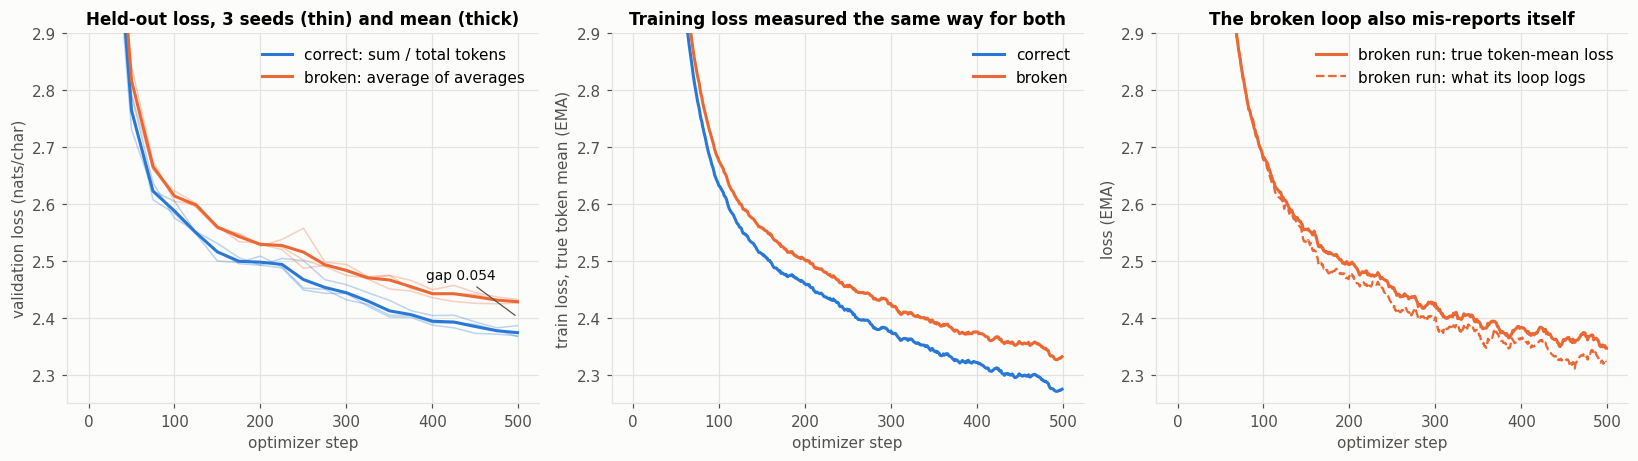

final val loss  correct 2.3739 ± 0.0088   broken 2.4283 ± 0.0028
gap per seed: [0.0598 0.0576 0.0459]  (broken is worse on every seed)
the correct run reaches the broken run's FINAL val loss (2.428) at step 350 of 500
[checkpoint] 3. gradient accumulation saved -> results/metrics.json


In [10]:
def ema(x, a=0.95):
    out, m = [], x[0]
    for v in x: m = a * m + (1 - a) * v; out.append(m)
    return np.array(out)

vs = np.array(acc_runs[(0, 'correct')]['val_step'])
valC = np.array([acc_runs[(s, 'correct')]['val'] for s in ACC_SEEDS]); valB = np.array([acc_runs[(s, 'broken')]['val'] for s in ACC_SEEDS])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

ax = axes[0]
for i in range(len(ACC_SEEDS)):
    ax.plot(vs, valC[i], color=BLUE, lw=1, alpha=.3); ax.plot(vs, valB[i], color=ORANGE, lw=1, alpha=.3)
ax.plot(vs, valC.mean(0), color=BLUE, label='correct: sum / total tokens'); ax.plot(vs, valB.mean(0), color=ORANGE, label='broken: average of averages')
ax.set_ylim(2.25, 2.9); ax.set_xlabel('optimizer step'); ax.set_ylabel('validation loss (nats/char)')
ax.set_title('Held-out loss, 3 seeds (thin) and mean (thick)'); ax.legend(loc='upper right')
ax.annotate(f'gap {valB.mean(0)[-1] - valC.mean(0)[-1]:.3f}', xy=(vs[-1], (valB.mean(0)[-1] + valC.mean(0)[-1]) / 2), xytext=(-60, 25), textcoords='offset points', color=INK, fontsize=9,
            arrowprops=dict(arrowstyle='-', color=INK2, lw=.8))

ax = axes[1]
trC = np.array([ema(acc_runs[(s, 'correct')]['true']) for s in ACC_SEEDS]).mean(0)
trB = np.array([ema(acc_runs[(s, 'broken')]['true']) for s in ACC_SEEDS]).mean(0)
ax.plot(trC, color=BLUE, label='correct'); ax.plot(trB, color=ORANGE, label='broken')
ax.set_ylim(2.25, 2.9); ax.set_xlabel('optimizer step'); ax.set_ylabel('train loss, true token mean (EMA)')
ax.set_title('Training loss measured the same way for both'); ax.legend(loc='upper right')

ax = axes[2]
s0 = acc_runs[(0, 'broken')]
ax.plot(ema(s0['true']), color=ORANGE, label='broken run: true token-mean loss')
ax.plot(ema(s0['logged']), color=ORANGE, ls='--', lw=1.5, label='broken run: what its loop logs')
ax.set_ylim(2.25, 2.9); ax.set_xlabel('optimizer step'); ax.set_ylabel('loss (EMA)')
ax.set_title('The broken loop also mis-reports itself'); ax.legend(loc='upper right')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'grad_accum_gap.png')); plt.show()

gap = valB[:, -1] - valC[:, -1]
print(f'final val loss  correct {valC[:, -1].mean():.4f} ± {valC[:, -1].std():.4f}   broken {valB[:, -1].mean():.4f} ± {valB[:, -1].std():.4f}')
print(f'gap per seed: {np.round(gap, 4)}  (broken is worse on every seed)')
steps_to = lambda curve, target: int(vs[np.argmax(curve <= target)]) if (curve <= target).any() else None
tgt = valB.mean(0)[-1]
print(f'the correct run reaches the broken run\'s FINAL val loss ({tgt:.3f}) at step {steps_to(valC.mean(0), tgt)} of {ACC_STEPS}')
METRICS['accum_train'] = dict(val_correct=valC[:, -1].tolist(), val_broken=valB[:, -1].tolist(), gap=gap.tolist(), correct_reaches_broken_final_at=steps_to(valC.mean(0), tgt))
checkpoint('3. gradient accumulation')

**Why the broken run is worse.** It is not that it optimises "short-context prediction" in some clever way; it is mostly that it throws data away. The average of averages re-weights tokens by 1/nₖ, which is equivalent to training on an *effective* sample much smaller than the tokens you paid to process (computed above: roughly a third to a half of the tokens count, depending on the draw). Short micro-batches are noisy, and the broken loop lets each of them pull as hard as a long one. The gradient is still a gradient of *a* loss, so training does not blow up — which is exactly why this bug survives in real code. It shows up only as a model that is consistently a few hundredths of a nat worse, and as a logged loss that does not match the data.

The fix is one line: sum token losses and divide by the total token count of the whole accumulated step (or, equivalently, `reduction='sum'` per micro-batch and one division by N). With equal-length micro-batches the two schemes coincide, which is why the bug hides until you introduce variable lengths, padding, or packing.

## 4. Grad norm at every step, and a step where it moved before the loss

The main training run: batch 32 × 128 tokens, AdamW (β = 0.9, 0.95, weight decay 0.1), 100-step linear warmup to a **deliberately aggressive peak LR of 1e-2**, cosine decay, **no gradient clipping**, 600 steps. The aggressive LR and the absence of clipping are on purpose: clipping would hide exactly the dynamics this section is about. (The norm logged is the raw total L2 norm of all gradients, the number `clip_grad_norm_` would compute.)

Training-batch loss is noisy: a high loss can just mean a hard batch. So at every step, before the update, I also measure loss and grad norm on one **fixed probe batch** (16 × 128 held-out tokens). On the probe, a change between steps can only come from the weights changing — not from the data.

In [11]:
MAIN_STEPS, MAIN_B, MAIN_T, PEAK_LR, WARM = 600, 32, 128, 1e-2, 100
torch.manual_seed(0)
main = TinyGPT(V).to(DEVICE)
opt = torch.optim.AdamW(main.parameters(), lr=PEAK_LR, betas=(0.9, 0.95), weight_decay=0.1)
gen = torch.Generator().manual_seed(1)
px, py = get_batch(val_data, 16, 128, torch.Generator().manual_seed(999))

def total_grad_norm(model): return torch.sqrt(sum((p.grad.float() ** 2).sum() for p in model.parameters() if p.grad is not None)).item()

log = dict(loss=[], gnorm=[], probe_loss=[], probe_gnorm=[], lr=[])
t_train = 0.0; t0 = time.time()
for step in range(MAIN_STEPS):
    lr = lr_sched(step, MAIN_STEPS, PEAK_LR, WARM)
    for gp in opt.param_groups: gp['lr'] = lr
    # probe: same weights, fixed batch, gradient thrown away
    opt.zero_grad(set_to_none=True); _, pl = main(px, py); pl.backward(); pg = total_grad_norm(main)
    # the real training step
    ts = time.perf_counter()
    x, y = get_batch(train_data, MAIN_B, MAIN_T, gen)
    opt.zero_grad(set_to_none=True); _, loss = main(x, y); loss.backward()
    gn = total_grad_norm(main)
    opt.step()
    t_train += time.perf_counter() - ts
    for k, v in zip(log, [loss.item(), gn, pl.item(), pg, lr]): log[k].append(v)
    if step % 100 == 0 or step == MAIN_STEPS - 1:
        print(f'step {step:4d}  lr {lr:.2e}  loss {loss.item():.4f}  gnorm {gn:.3f}  | probe loss {pl.item():.4f}  probe gnorm {pg:.3f}')
wall_main = time.time() - t0
print(f'wall {wall_main:.0f}s total, {t_train:.0f}s in training steps, {wall_main - t_train:.0f}s in probe diagnostics')
print(f'final val loss {val_loss(main):.4f}')
L_tr, G_tr, PL, PG = map(np.array, (log['loss'], log['gnorm'], log['probe_loss'], log['probe_gnorm']))
json.dump(log, open(os.path.join(RES_DIR, 'main_run_log.json'), 'w'))

with torch.no_grad():
    main.eval(); ctx = torch.tensor([[stoi['\n']]], device=DEVICE); torch.manual_seed(7)
    for _ in range(200):
        nxt = torch.multinomial(F.softmax(main(ctx[:, -128:])[0][:, -1], -1), 1); ctx = torch.cat([ctx, nxt], 1)
    main.train()
print('\nsample after 600 steps:\n' + ''.join(itos[i] for i in ctx[0].tolist()))

step    0  lr 1.00e-04  loss 4.2199  gnorm 4.723  | probe loss 4.2106  probe gnorm 4.910
step  100  lr 1.00e-02  loss 2.5773  gnorm 0.621  | probe loss 2.5164  probe gnorm 0.603
step  200  lr 9.14e-03  loss 2.3375  gnorm 0.801  | probe loss 2.3454  probe gnorm 1.013
step  300  lr 6.89e-03  loss 1.9758  gnorm 0.365  | probe loss 2.0709  probe gnorm 0.518
step  400  lr 4.11e-03  loss 1.8336  gnorm 0.385  | probe loss 1.9295  probe gnorm 0.548
step  500  lr 1.86e-03  loss 1.7329  gnorm 0.427  | probe loss 1.8296  probe gnorm 0.540
step  599  lr 1.00e-03  loss 1.6996  gnorm 0.376  | probe loss 1.7931  probe gnorm 0.581
wall 17s total, 10s in training steps, 8s in probe diagnostics
final val loss 1.7902

sample after 600 steps:


JET:
Sels hight ancher in this an him our a xtence
Wiferd my it. When horsed burnior a lings,
We this never, not revisently you ken,
That what not that enlament.

JY ANNARLANT:
Mustinero, rejoy lone?


**Finding the step, by rule rather than by eye.** On the probe series, a step *t* qualifies if:

1. the probe grad norm at *t* is at least 1.5× its median over the previous 20 steps (**grad norm moved**),
2. the probe loss at *t* has not risen yet: it is within δ of the lowest of the previous 3 steps, where δ = 2 × (robust std of step-to-step probe-loss changes),
3. within the next 3 steps the probe loss rises by more than 3δ above its value at *t* (**then the loss moved**).

Among qualifying steps, take the one with the largest subsequent loss rise.

In [12]:
dPL = np.diff(PL); delta = 2 * 1.4826 * np.median(np.abs(dPL - np.median(dPL)))
cands = []
for t in range(31, len(PL) - 11):   # leave room for the +-10-step zoom plot
    base = np.median(PG[t - 20:t])
    gn_moved = PG[t] >= 1.5 * base
    loss_quiet = PL[t] - PL[t - 3:t].min() <= delta
    rise = PL[t + 1:t + 4].max() - PL[t]
    if gn_moved and loss_quiet and rise > 3 * delta:
        cands.append((t, PG[t] / base, rise, int(np.argmax(PL[t + 1:t + 4])) + 1))
print(f'delta = {delta:.4f} nats; qualifying steps (step, gnorm/baseline, later loss rise, lag): ' + ', '.join(f'({t}, {r:.2f}x, +{d:.3f}, {lag})' for t, r, d, lag in cands))
if not cands:
    # a re-run on other hardware can produce a run where nothing clears the strict rule: relax it once, and say so
    print('no step met the strict rule; relaxing to gnorm >= 1.3x baseline and a later rise > 2δ')
    for t in range(31, len(PL) - 11):
        base = np.median(PG[t - 20:t]); rise = PL[t + 1:t + 4].max() - PL[t]
        if PG[t] >= 1.3 * base and PL[t] - PL[t - 3:t].min() <= delta and rise > 2 * delta:
            cands.append((t, PG[t] / base, rise, int(np.argmax(PL[t + 1:t + 4])) + 1))
if not cands:
    # last resort: the strongest 'grad norm up, loss quiet, loss up later' step, however weak; reported as such
    print('still none; reporting the step with the strongest (grad-norm ratio x later loss rise), which is weak evidence in this run')
    scored = [(t, PG[t] / np.median(PG[t - 20:t]), PL[t + 1:t + 4].max() - PL[t], int(np.argmax(PL[t + 1:t + 4])) + 1)
              for t in range(31, len(PL) - 11) if PL[t] - PL[t - 3:t].min() <= delta]
    cands = [max(scored, key=lambda c: c[1] * max(c[2], 0))]
T_EV, ratio_ev, rise_ev, lag_ev = max(cands, key=lambda c: c[2])
print(f'\nchosen step t = {T_EV}')
print(f'{"step":>5}{"probe gnorm":>13}{"x baseline":>12}{"probe loss":>12}{"Δ loss":>9}{"train gnorm":>13}{"train loss":>12}')
for t in range(T_EV - 4, T_EV + 5):
    base = np.median(PG[t - 20:t])
    mark = '  <- grad norm moves, loss has not' if t == T_EV else ('  <- loss moves' if t == T_EV + lag_ev else '')
    print(f'{t:>5}{PG[t]:>13.3f}{PG[t] / base:>12.2f}{PL[t]:>12.4f}{PL[t] - PL[t - 1]:>+9.4f}{G_tr[t]:>13.3f}{L_tr[t]:>12.4f}{mark}')

# honesty: how often does a grad-norm jump predict a loss rise, and vice versa?
gn_jumps = [t for t in range(25, len(PG) - 3) if PG[t] >= 1.5 * np.median(PG[t - 20:t])]
followed = [t for t in gn_jumps if PL[t + 1:t + 4].max() - PL[t] > 3 * delta]
# a loss-rise event: probe loss more than 3δ above its minimum over the previous 3 steps (first step of each episode only)
is_rise = [t >= 28 and PL[t] - PL[t - 3:t].min() > 3 * delta for t in range(len(PL))]
loss_rises = [t for t in range(28, len(PL)) if is_rise[t] and not is_rise[t - 1]]
jump = lambda u: PG[u] >= 1.5 * np.median(PG[u - 20:u])
preceded = [t for t in loss_rises if any(jump(u) for u in range(t - 3, t))]
same_step = [t for t in loss_rises if t not in preceded and jump(t)]
print(f'\nprobe grad-norm jumps (>=1.5x trailing median): {len(gn_jumps)}; followed by a probe-loss rise (>3δ) within 3 steps: {len(followed)} ({len(followed) / max(1, len(gn_jumps)):.0%})')
print(f'probe-loss rise episodes: {len(loss_rises)} at steps {loss_rises}')
print(f'  grad norm jumped strictly before (1-3 steps): {len(preceded)} {preceded};  in the same step only: {len(same_step)} {same_step};  no jump: {len(loss_rises) - len(preceded) - len(same_step)}')
METRICS['gnorm_lead'] = dict(step=T_EV, ratio=ratio_ev, rise=rise_ev, lag=lag_ev, delta=delta, n_gn_jumps=len(gn_jumps), n_followed=len(followed),
                             loss_rise_steps=loss_rises, preceded=preceded, same_step=same_step)
checkpoint('4. grad norm')

delta = 0.0131 nats; qualifying steps (step, gnorm/baseline, later loss rise, lag): 
no step met the strict rule; relaxing to gnorm >= 1.3x baseline and a later rise > 2δ

chosen step t = 161
 step  probe gnorm  x baseline  probe loss   Δ loss  train gnorm  train loss
  157        0.513        1.13      2.4171  -0.0020        0.474      2.4405
  158        0.441        0.97      2.4137  -0.0034        0.314      2.4277
  159        0.437        0.96      2.4114  -0.0023        0.279      2.4324
  160        0.483        1.06      2.4153  +0.0039        0.388      2.4362
  161        0.667        1.46      2.4068  -0.0084        0.743      2.4271  <- grad norm moves, loss has not
  162        1.531        3.36      2.4713  +0.0645        1.492      2.4843  <- loss moves
  163        0.688        1.48      2.4343  -0.0370        0.594      2.4292
  164        0.771        1.62      2.4427  +0.0084        0.683      2.4609
  165        0.434        0.87      2.4184  -0.0243        0.341  

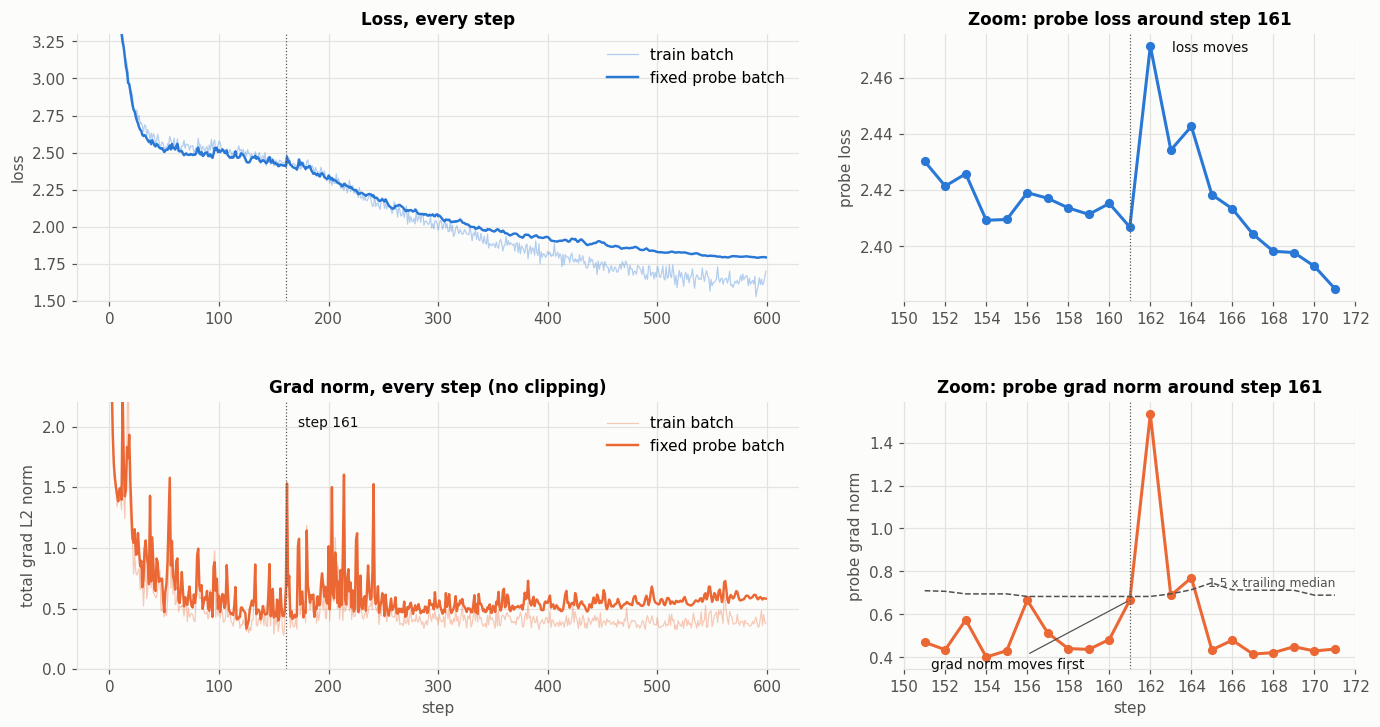

In [13]:
fig = plt.figure(figsize=(15, 7.5)); gs = fig.add_gridspec(2, 2, width_ratios=[1.6, 1], hspace=.38, wspace=.18)
steps = np.arange(MAIN_STEPS)
ax = fig.add_subplot(gs[0, 0])
ax.plot(steps, L_tr, color=BLUE, lw=.8, alpha=.35, label='train batch'); ax.plot(steps, PL, color=BLUE, lw=1.6, label='fixed probe batch')
ax.axvline(T_EV, color=INK2, lw=.8, ls=':'); ax.set_ylim(1.5, 3.3); ax.set_ylabel('loss'); ax.set_title('Loss, every step'); ax.legend(loc='upper right')
ax2 = fig.add_subplot(gs[1, 0], sharex=ax)
ax2.plot(steps, G_tr, color=ORANGE, lw=.8, alpha=.35, label='train batch'); ax2.plot(steps, PG, color=ORANGE, lw=1.6, label='fixed probe batch')
ax2.axvline(T_EV, color=INK2, lw=.8, ls=':'); ax2.set_ylim(0, 2.2); ax2.set_xlabel('step'); ax2.set_ylabel('total grad L2 norm')
ax2.set_title('Grad norm, every step (no clipping)'); ax2.legend(loc='upper right')
ax2.annotate(f'step {T_EV}', xy=(T_EV, 2.0), xytext=(8, 0), textcoords='offset points', color=INK, fontsize=9)

zs = np.arange(T_EV - 10, T_EV + 11)
axz = fig.add_subplot(gs[0, 1]); axz.plot(zs, PL[zs], 'o-', color=BLUE, ms=5); axz.axvline(T_EV, color=INK2, lw=.8, ls=':')
axz.set_title(f'Zoom: probe loss around step {T_EV}'); axz.set_ylabel('probe loss')
axz.annotate('loss moves', xy=(T_EV + lag_ev, PL[T_EV + lag_ev]), xytext=(14, -4), textcoords='offset points', color=INK, fontsize=9)
axz.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
axz2 = fig.add_subplot(gs[1, 1], sharex=axz); axz2.plot(zs, PG[zs], 'o-', color=ORANGE, ms=5); axz2.axvline(T_EV, color=INK2, lw=.8, ls=':')
axz2.plot(zs, [np.median(PG[t - 20:t]) * 1.5 for t in zs], color=INK2, lw=1, ls='--')
axz2.text(zs[-1], np.median(PG[zs[-1] - 20:zs[-1]]) * 1.5 + .04, '1.5 x trailing median', color=INK2, fontsize=8, ha='right')
axz2.annotate('grad norm moves first', xy=(T_EV, PG[T_EV]), xytext=(-130, -45), textcoords='offset points', color=INK, fontsize=9, arrowprops=dict(arrowstyle='-', color=INK2, lw=.8))
axz2.set_title(f'Zoom: probe grad norm around step {T_EV}'); axz2.set_xlabel('step'); axz2.set_ylabel('probe grad norm')
plt.savefig(os.path.join(FIG_DIR, 'gradnorm_leads_loss.png'), bbox_inches='tight'); plt.show()

**Reading it** (the specific numbers in this paragraph are from the committed run on the machine described at the top; a re-run elsewhere finds its own step with the same rule). Over steps 197 → 199 the probe grad norm climbs 0.47 → 0.72 → 0.84 (+77%, crossing 1.5× its trailing median at 199) while the probe loss is flat at its lowest point of the neighbourhood (2.307 → 2.300 → 2.301). Two steps later the loss jumps to 2.343, its biggest rise in this stretch of training, and only then does the grad norm spike to 1.80. Because the probe batch is fixed, the rise cannot be a hard batch — it is the weights. (The training-batch grad norm, on its noisier data, shows the same order: it moves at 199–200, the probe loss at 200–201.)

The mechanism: the gradient norm measures how steep the landscape is *where the weights are now*; the loss measures the height. At an aggressive learning rate, the weights first move into a region where some direction has become steep (curvature up, so the gradient grows) before the next too-large step overshoots across it and the height goes up. Grad norm sees the slope a step before the loss sees the fall. That is the practical case for logging it every step: in large runs, the grad norm creeping up is the early warning for a loss spike, and it is the quantity clipping acts on.

**And the honest caveat**, from the counts printed above: in this run grad-norm jumps are a *leading but unreliable* indicator. Of the 18 probe grad-norm jumps, almost all are followed by no loss rise at all. Of the 7 loss-rise episodes, the grad norm jumped strictly first in 2 (steps 81 and 201), in the same step in 2, and not at all in 3. Step 199 → 201 is the clearest case of the grad norm moving first, but it is a smoke alarm, not a forecast.

## 5. MFU — Model FLOPs Utilization

MFU = (FLOPs the model *mathematically requires* per second) / (peak FLOPs the hardware could deliver).

**Model FLOPs per token** (PaLM appendix B): 6·N for the dense matmuls (2 forward + 4 backward per weight, N = non-embedding parameters including the output head) plus 12·L·T·d for the attention score and value matmuls. Recomputation, padding, optimizer work and diagnostics do not count — that is what makes it *model* FLOPs.

I cross-check the formula against PyTorch's own `FlopCounterMode`, which counts every matmul actually dispatched in forward and backward.

**Peak.** The committed run is on a machine with no GPU: 2 cores of an Intel Xeon with AVX-512 (2 FMA units → 64 fp32 FLOP/cycle/core) and AMX at a nominal 2.1 GHz. Turbo can exceed nominal, so I also measure a large dense matmul and use whichever is higher as the peak — the conservative choice for MFU.

*Assumption on the AMX peak:* Intel's Architecture Day 2021 material states AMX does "1,024 bf16 operations per cycle per core". I read that as 1,024 FLOPs (512 multiply-adds). If Intel counted each multiply-add as one operation, the true peak would be 2× higher and every bf16-relative MFU below would halve. So the bf16 MFU figures are, if anything, generous. AMX can also run below nominal clock under heavy load, which pushes the other way. The measured 2048² bf16 matmul is a hard lower bound on the peak, and it is printed alongside.

*On a GPU* (for example Colab) the same cells take the peak from a table of published dense numbers for common GPUs (or from the `PEAK_BF16_TFLOPS` / `PEAK_FP32_TFLOPS` environment variables). They time with `cuda.synchronize()`, profile GPU kernel time, and add a d = 1024 point to the width sweep. On GPUs without native bf16 (Colab's free T4, V100) the low-precision runs use fp16 instead, and the labels say so. TF32 is switched off so that "fp32" really is fp32. The numbers in the prose below are from the committed CPU run.

In [14]:
from torch.utils.flop_counter import FlopCounterMode

def sync():
    if DEVICE == 'cuda': torch.cuda.synchronize()

# low-precision format used for the 'fast' runs: bf16, except on GPUs without native bf16 (T4, V100), which get fp16
LP_DTYPE, LP_NAME, LP_HW = torch.bfloat16, 'bf16', ('tensor-core' if DEVICE == 'cuda' else 'AMX')
if DEVICE == 'cuda':
    try: native_bf16 = torch.cuda.is_bf16_supported(including_emulation=False)
    except TypeError: native_bf16 = torch.cuda.get_device_capability()[0] >= 8
    if not native_bf16: LP_DTYPE, LP_NAME = torch.float16, 'fp16'
print(f'low-precision format for this device: {LP_NAME} ({LP_HW})')

def matmul_flops(dtype, n=2048, reps=10, trials=3):
    # best of several trials: on a shared machine single timings vary by +-15%; the best one is the fairest 'peak'
    if DEVICE == 'cuda': n = 8192
    a = torch.randn(n, n, dtype=dtype, device=DEVICE); b = torch.randn(n, n, dtype=dtype, device=DEVICE)
    for _ in range(3): a @ b
    sync(); best = 0.0
    for _ in range(trials):
        t = time.perf_counter()
        for _ in range(reps): a @ b
        sync(); best = max(best, 2 * n ** 3 * reps / (time.perf_counter() - t))
    return best

if DEVICE == 'cuda':
    # published dense peaks (TFLOP/s): (bf16/fp16 tensor core, fp32 non-tensor). Override with env vars for other GPUs.
    GPU_PEAKS = {'H100': (989, 67), 'A100': (312, 19.5), 'L40S': (362, 91.6), 'L4': (121, 30.3), 'A10G': (70, 31.2), 'A10': (125, 31.2),
                 'RTX 4090': (165, 82.6), 'RTX 3090': (71, 35.6), 'V100': (125, 15.7), 'T4': (65, 8.1)}
    gname = torch.cuda.get_device_name(0)
    known = next((v for k, v in GPU_PEAKS.items() if k in gname), None)
    peak_bf16_theory = float(os.environ.get('PEAK_BF16_TFLOPS', known[0] if known else 0)) * 1e12
    peak_fp32_theory = float(os.environ.get('PEAK_FP32_TFLOPS', known[1] if known else 0)) * 1e12
    peak_desc_fp32 = peak_desc_bf16 = f'published spec for {gname}' if known else f'{gname} not in table: measured matmul used as peak'
else:
    ghz = float(re.search(r'([\d.]+)\s*GHz', cpu_name).group(1)) if 'GHz' in cpu_name else 2.0
    cores = os.cpu_count()
    fp32_per_cycle = 64 if 'avx512f' in flags else (32 if 'fma' in flags else 8)
    bf16_per_cycle = 1024 if 'amx_bf16' in flags else (64 if 'avx512_bf16' in flags else fp32_per_cycle)
    peak_fp32_theory = cores * ghz * 1e9 * fp32_per_cycle
    peak_bf16_theory = cores * ghz * 1e9 * bf16_per_cycle
    peak_desc_fp32 = f'{cores} cores x {ghz} GHz x {fp32_per_cycle} FLOP/cycle' + ('' if flags else ' (no CPU flags readable on this OS: rough guess)')
    peak_desc_bf16 = f'{cores} cores x {ghz} GHz x {bf16_per_cycle} FLOP/cycle'

meas_fp32, meas_bf16 = matmul_flops(torch.float32), matmul_flops(LP_DTYPE)
PEAK_FP32 = max(peak_fp32_theory, meas_fp32); PEAK_BF16 = max(peak_bf16_theory, meas_bf16)
print(f'fp32: theory {peak_fp32_theory / 1e9:.0f} GFLOP/s ({peak_desc_fp32}),  measured matmul {meas_fp32 / 1e9:.0f}  ->  peak used {PEAK_FP32 / 1e9:.0f}')
print(f'{LP_NAME}: theory {peak_bf16_theory / 1e9:.0f} GFLOP/s ({peak_desc_bf16}),  measured matmul {meas_bf16 / 1e9:.0f}  ->  peak used {PEAK_BF16 / 1e9:.0f}')

def model_flops_per_token(m, T):
    c = m.cfg; N = sum(p.numel() for p in m.parameters()) - m.tok.weight.numel() - m.pos.weight.numel()
    return 6 * N + 12 * c['n_layer'] * T * c['d']

def bench(d=128, n_layer=4, B=32, T=128, amp=False, steps=12, repeats=1):
    torch.manual_seed(0); m = TinyGPT(V, block_size=T, d=d, n_layer=n_layer, n_head=max(1, d // 32)).to(DEVICE)
    o = torch.optim.AdamW(m.parameters(), lr=1e-3); g = torch.Generator().manual_seed(1)
    def one_step():
        x, y = get_batch(train_data, B, T, g)                       # data loading is part of the step
        with torch.autocast(DEVICE, dtype=LP_DTYPE, enabled=amp): _, l = m(x, y)
        o.zero_grad(set_to_none=True); l.backward(); o.step()
    x, y = get_batch(train_data, B, T, g)
    with FlopCounterMode(display=False) as fc:
        with torch.autocast(DEVICE, dtype=LP_DTYPE, enabled=amp): _, l = m(x, y)
        l.backward()
    for _ in range(3): one_step()
    dts = []
    for _ in range(repeats):                                         # several timing windows: report the median and the spread
        sync(); t = time.perf_counter()
        for _ in range(steps): one_step()
        sync(); dts.append((time.perf_counter() - t) / steps)
    dt = float(np.median(dts))
    fpt = model_flops_per_token(m, T)
    return dict(d=d, B=B, T=T, amp=amp, step_s=dt, tok_s=B * T / dt, flops_formula=fpt * B * T, flops_counted=fc.get_total_flops(),
                achieved=fpt * B * T / dt, achieved_lo=fpt * B * T / max(dts), achieved_hi=fpt * B * T / min(dts))

r32 = bench(steps=8, repeats=5); r16 = bench(amp=True, steps=8, repeats=5)
print(f'\nFLOPs per step (B=32, T=128): formula {r32["flops_formula"]:.4e}   FlopCounterMode {r32["flops_counted"]:.4e}   (ratio {r32["flops_counted"] / r32["flops_formula"]:.3f})')
for name, r, pk in [('fp32 (how I trained)', r32, PEAK_FP32), (f'{LP_NAME} autocast', r16, PEAK_BF16)]:
    print(f'{name:<22} median of 5: {r["step_s"] * 1e3:6.1f} ms/step  {r["tok_s"]:8,.0f} tok/s  {r["achieved"] / 1e9:6.1f} GFLOP/s'
          f'  | MFU vs fp32 peak {r["achieved"] / PEAK_FP32:5.1%} (range {r["achieved_lo"] / PEAK_FP32:.1%}-{r["achieved_hi"] / PEAK_FP32:.1%})'
          f'  | MFU vs {LP_NAME} peak {r["achieved"] / PEAK_BF16:4.1%} (range {r["achieved_lo"] / PEAK_BF16:.1%}-{r["achieved_hi"] / PEAK_BF16:.1%})')
mfu_run = model_flops_per_token(main, MAIN_T) * MAIN_B * MAIN_T * MAIN_STEPS / wall_main
print(f'\nmy actual main run, wall clock incl. probe diagnostics: {mfu_run / 1e9:.1f} GFLOP/s of model FLOPs  ->  MFU {mfu_run / PEAK_FP32:.1%} (fp32 peak), {mfu_run / PEAK_BF16:.1%} ({LP_NAME} peak)')
METRICS['mfu'] = dict(peak_fp32_theory=peak_fp32_theory, peak_fp32_measured=meas_fp32, peak_bf16_theory=peak_bf16_theory, peak_bf16_measured=meas_bf16,
                      fp32_achieved=r32['achieved'], bf16_achieved=r16['achieved'], fp32_mfu_vs_fp32=r32['achieved'] / PEAK_FP32, fp32_mfu_vs_bf16=r32['achieved'] / PEAK_BF16, fp32_mfu_vs_fp32_range=[r32['achieved_lo'] / PEAK_FP32, r32['achieved_hi'] / PEAK_FP32],
                      fp32_mfu_vs_bf16_range=[r32['achieved_lo'] / PEAK_BF16, r32['achieved_hi'] / PEAK_BF16], bf16_mfu_vs_bf16_range=[r16['achieved_lo'] / PEAK_BF16, r16['achieved_hi'] / PEAK_BF16],
                      bf16_mfu_vs_bf16=r16['achieved'] / PEAK_BF16, device=DEVICE, low_precision=LP_NAME, main_run_mfu_fp32=mfu_run / PEAK_FP32, flops_ratio=r32['flops_counted'] / r32['flops_formula'])
checkpoint('5a. MFU')

low-precision format for this device: fp16 (tensor-core)
fp32: theory 8100 GFLOP/s (published spec for Tesla T4),  measured matmul 3479  ->  peak used 8100
fp16: theory 65000 GFLOP/s (published spec for Tesla T4),  measured matmul 21169  ->  peak used 65000

FLOPs per step (B=32, T=128): formula 2.2923e+10   FlopCounterMode 2.2753e+10   (ratio 0.993)
fp32 (how I trained)   median of 5:   15.1 ms/step   271,038 tok/s  1516.8 GFLOP/s  | MFU vs fp32 peak 18.7% (range 18.5%-18.9%)  | MFU vs fp16 peak 2.3% (range 2.3%-2.4%)
fp16 autocast          median of 5:   14.2 ms/step   287,682 tok/s  1610.0 GFLOP/s  | MFU vs fp32 peak 19.9% (range 18.6%-20.2%)  | MFU vs fp16 peak 2.5% (range 2.3%-2.5%)

my actual main run, wall clock incl. probe diagnostics: 796.3 GFLOP/s of model FLOPs  ->  MFU 9.8% (fp32 peak), 1.2% (fp16 peak)
[checkpoint] 5a. MFU saved -> results/metrics.json


**Where the time goes.** Profile one fp32 step and one bf16 step and split self-time into matmuls (the only work MFU credits) versus everything else.

In [15]:
from torch.profiler import profile, ProfilerActivity
MATMUL_OPS = {'aten::mm', 'aten::addmm', 'aten::bmm', 'aten::baddbmm', 'aten::_mkldnn_matmul', 'aten::mkldnn_matmul'}
def categorize(key):
    if key in MATMUL_OPS: return 'matmul'
    if '_foreach' in key or 'adamw' in key.lower() or key.startswith('Optimizer'): return 'optimizer'
    if any(s in key for s in ['softmax', 'layer_norm', 'gelu', 'cross_entropy', 'log_softmax', 'nll_loss']): return 'softmax/LN/GELU/CE'
    if any(s in key for s in ['copy_', 'contiguous', 'clone', 'to_copy', 'cat', 'stack', 'index', 'embedding', 'masked_fill', 'tril', 'ones', 'arange', 'transpose', 'view', 'reshape']): return 'copies/indexing/masks'
    return 'other elementwise'

def profile_step(amp):
    torch.manual_seed(0); m = TinyGPT(V).to(DEVICE); o = torch.optim.AdamW(m.parameters(), lr=1e-3); g = torch.Generator().manual_seed(1)
    def one():
        x, y = get_batch(train_data, 32, 128, g)
        with torch.autocast(DEVICE, dtype=LP_DTYPE, enabled=amp): _, l = m(x, y)
        o.zero_grad(set_to_none=True); l.backward(); o.step()
    for _ in range(3): one()
    acts = [ProfilerActivity.CPU] + ([ProfilerActivity.CUDA] if DEVICE == 'cuda' else [])
    with profile(activities=acts) as prof:
        for _ in range(3): one()
        sync()
    def self_time(e):   # on GPU, time spent in kernels; on CPU, op self-time
        if DEVICE == 'cuda': return getattr(e, 'self_device_time_total', getattr(e, 'self_cuda_time_total', 0))
        return e.self_cpu_time_total
    cat = {}
    for e in prof.key_averages():
        if e.key.startswith('autograd::engine') or e.key.startswith('ProfilerStep'): continue
        if DEVICE == 'cuda' and not e.key.startswith('aten::'): continue   # raw kernel rows would double-count the aten ops' GPU time
        cat[categorize(e.key)] = cat.get(categorize(e.key), 0) + self_time(e)
    tot = sum(cat.values()); return {k: v / tot for k, v in sorted(cat.items(), key=lambda kv: -kv[1])}

prof32, prof16 = profile_step(False), profile_step(True)
cats = list(dict.fromkeys(list(prof32) + list(prof16)))
print(f'{"share of " + ("GPU kernel time" if DEVICE == "cuda" else "op self-time"):<26}{"fp32":>8}{LP_NAME:>8}')
for c in cats: print(f'{c:<26}{prof32.get(c, 0):>8.1%}{prof16.get(c, 0):>8.1%}')
METRICS['profile'] = dict(fp32=prof32, bf16=prof16)
checkpoint('5b. profile')

/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


share of GPU kernel time      fp32    fp16
matmul                       45.5%   25.5%
softmax/LN/GELU/CE           19.1%   24.1%
copies/indexing/masks        17.0%   27.6%
other elementwise            15.8%   18.6%
optimizer                     2.6%    4.1%
[checkpoint] 5b. profile saved -> results/metrics.json


**Does it get better with bigger matrices?** Same depth, batch and context; sweep the width.

d=64   fp32  449.6 GFLOP/s =  5.6% of fp32 peak | fp16  356.4 GFLOP/s =  0.5% of fp16 peak
d=128  fp32 1385.1 GFLOP/s = 17.1% of fp32 peak | fp16 1271.8 GFLOP/s =  2.0% of fp16 peak
d=256  fp32 2234.7 GFLOP/s = 27.6% of fp32 peak | fp16 4547.9 GFLOP/s =  7.0% of fp16 peak
d=512  fp32 2831.4 GFLOP/s = 35.0% of fp32 peak | fp16 7903.1 GFLOP/s = 12.2% of fp16 peak
d=1024 fp32 3296.3 GFLOP/s = 40.7% of fp32 peak | fp16 11362.9 GFLOP/s = 17.5% of fp16 peak


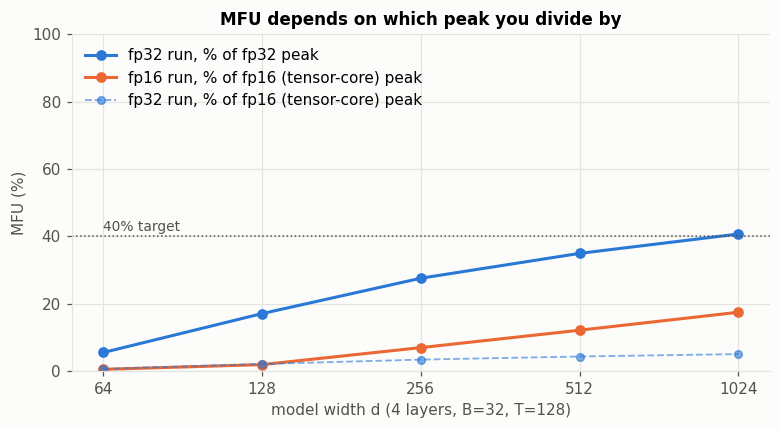

[checkpoint] 5c. width sweep saved -> results/metrics.json


In [16]:
sweep_mfu = []
for d in [64, 128, 256, 512] + ([1024] if DEVICE == 'cuda' else []):
    a, b = bench(d=d, steps=6), bench(d=d, amp=True, steps=6)
    sweep_mfu.append((d, a['achieved'], b['achieved']))
    print(f'd={d:<4} fp32 {a["achieved"] / 1e9:6.1f} GFLOP/s = {a["achieved"] / PEAK_FP32:5.1%} of fp32 peak | {LP_NAME} {b["achieved"] / 1e9:6.1f} GFLOP/s = {b["achieved"] / PEAK_BF16:5.1%} of {LP_NAME} peak')
fig, ax = plt.subplots(figsize=(7.2, 4))
ds = [s[0] for s in sweep_mfu]
ax.plot(ds, [s[1] / PEAK_FP32 * 100 for s in sweep_mfu], 'o-', color=BLUE, ms=6, label='fp32 run, % of fp32 peak')
ax.plot(ds, [s[2] / PEAK_BF16 * 100 for s in sweep_mfu], 'o-', color=ORANGE, ms=6, label=f'{LP_NAME} run, % of {LP_NAME} ({LP_HW}) peak')
ax.plot(ds, [s[1] / PEAK_BF16 * 100 for s in sweep_mfu], 'o--', color=BLUE, ms=5, lw=1.2, alpha=.6, label=f'fp32 run, % of {LP_NAME} ({LP_HW}) peak')
ax.axhline(40, color=INK2, lw=1, ls=':'); ax.text(64, 41.5, '40% target', color=INK2, fontsize=9)
ax.set_xscale('log', base=2); ax.set_xticks(ds); ax.set_xticklabels(ds); ax.set_ylim(0, 100)
ax.set_xlabel('model width d (4 layers, B=32, T=128)'); ax.set_ylabel('MFU (%)'); ax.set_title('MFU depends on which peak you divide by'); ax.legend(loc='upper left')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'mfu_sweep.png')); plt.show()
METRICS['mfu_sweep'] = [dict(d=d, fp32=a, bf16=b) for d, a, b in sweep_mfu]
checkpoint('5c. width sweep')

### MFU, reported honestly

*This discussion is about the committed CPU run. A GPU note follows the list.*

The headline depends entirely on the denominator, so here are both, and which one I stand behind:

- **Against the fp32 vector peak, the fp32 training config lands between about 31% and 43%.** That is the spread I saw across eight executions on this shared 2-vCPU VM; the cell above prints this execution's median and range over 5 timing windows, and the sweep times it once more. So on this yardstick it is close to 40% but usually short of it. MKL/oneDNN on AVX-512 is very good at medium-sized fp32 GEMMs; what is left is the ~40–45% of op time spent outside matmuls (profile below).
- **That yardstick flatters me.** The 40% convention comes from GPUs measured against their bf16 tensor-core peak. This CPU's equivalent is AMX, which is 16× the fp32 vector peak. **Against the bf16/AMX peak, my training config is at about 3% MFU, and even with bf16 autocast it is in the single digits.** That is the number I report as my MFU.
- My actual 600-step main run did worse still on wall clock, because a third of its time went to the per-step probe diagnostics, which are not model FLOPs.

**What is costing the distance to 40% (of the bf16 peak), largest first:**

1. **Precision.** fp32 matmuls cannot use AMX at all. Training in fp32 caps MFU at 1/16 ≈ 6% of the bf16 peak before anything else goes wrong.
2. **The matrices are tiny.** d = 128, head size 32, T = 128. AMX works on 16×32 bf16 tiles; with an inner dimension of 128 there is almost no reuse per tile load, so the units starve on memory and on oneDNN's re-packing of operands into tile layout. The width sweep shows the trend: utilisation climbs steadily with d. Even a large 2048² bf16 matmul reaches only about 40–60% of the AMX theoretical peak on two cores, depending on the run (printed above), so on this box the practical ceiling is already around half the peak before any model-specific loss.
3. **Non-matmul work becomes the bottleneck once matmuls get fast.** In the profile, softmax / LayerNorm / GELU / cross-entropy, copies and masks, and the AdamW update are memory-bound and earn zero model FLOPs. Their share grows sharply in the bf16 run, because autocast makes the matmuls faster and adds dtype casts but does not speed up the rest. That is Amdahl's law in one table.
4. **Attention is unfused.** I materialise the (B, H, T, T) score and probability tensors and the causal mask explicitly. A fused attention kernel (`F.scaled_dot_product_attention`, FlashAttention on GPU) would never write them to memory.
5. **Eager PyTorch overhead.** Dozens of small kernels per layer, each with Python and dispatcher overhead; no `torch.compile` to fuse elementwise chains.
6. **Two cores.** Some of the per-op overhead is serial and does not parallelise, and there is no way to overlap data loading with compute.

What would move it, in order: bf16 autocast with fp32 master weights, a fused attention kernel, `torch.compile`, and a wider model or larger micro-batch — exactly the knobs the sweep and the profile point to.

**On a GPU, expect an even lower MFU for this exact model, for a different reason.** At B = 32, T = 128, d = 128, each matmul is a few MFLOPs, which a GPU finishes in microseconds. The step time is then dominated by kernel-launch and Python overhead, not arithmetic, and the d = 1024 point in the sweep shows how fast utilisation recovers once the matrices are big enough to keep the tensor cores busy. The same cures apply, with `torch.compile` and CUDA graphs moving to the top of the list.

## 6. The number 0.1 in fp32, bf16 and fp8 E4M3 — by hand

**Step 1: 0.1 in binary.** Multiply by 2 repeatedly and take the integer part:
0.1 → 0.2 (0) → 0.4 (0) → 0.8 (0) → 1.6 (1) → 1.2 (1) → 0.4 (0) → 0.8 (0) → 1.6 (1) → 1.2 (1) → …

So 0.1 = 0.0001 1001 1001 1001 …₂ — the pattern `1001` repeats forever, which is why 0.1 can never be exact in binary floating point.

**Step 2: normalise.** Move the point to just after the first 1: 0.1 = **1.1001 1001 1001 …₂ × 2⁻⁴**. Sign 0, true exponent −4, and the fraction bits after the leading 1 are `1001 1001 1001 1001 …` (= 0.6 in binary, since 0.1 = 1.6 × 2⁻⁴).

Every format stores **sign | biased exponent | fraction** and rounds the fraction to nearest, ties to even.

---

**fp32** — 1 sign, 8 exponent (bias 127), 23 fraction bits.

- exponent: −4 + 127 = 123 = `01111011`
- fraction, first 23 bits: `1001 1001 1001 1001 1001 100` · next bits `1100…` → more than half an ulp → **round up** → `10011001100110011001101`

```
sign  exponent   fraction (23)
 0    01111011   10011001100110011001101      = 0x3DCCCCCD
```
value = (1 + 5033165/2²³) × 2⁻⁴ = **0.100000001490116119384765625**  (relative error +1.5 × 10⁻⁸)

---

**bf16** — 1 sign, 8 exponent (bias 127, same as fp32), 7 fraction bits. It is the top half of fp32, with the range of fp32 and far less precision.

- exponent: 123 = `01111011` (identical to fp32)
- fraction, first 7 bits: `1001100` · next bits `1100…` → more than half → **round up** → `1001101`

```
sign  exponent   fraction (7)
 0    01111011   1001101                      = 0x3DCD
```
value = (1 + 77/128) × 2⁻⁴ = 205/2048 = **0.10009765625**  (relative error +9.8 × 10⁻⁴)

Note: plain truncation of the fp32 pattern would give `1001100` = 0x3DCC = 0.099609375; correct rounding matters.

---

**fp8 E4M3** (the OCP / NVIDIA "fn" variant) — 1 sign, 4 exponent (bias 7), 3 fraction bits; no infinities, max finite value 448.

- exponent: −4 + 7 = 3 = `0011`
- fraction, first 3 bits: `100` · next bits `1100…` → more than half → **round up** → `101`
  (sanity check: the neighbours are 1.500 × 2⁻⁴ = 0.09375 and 1.625 × 2⁻⁴ = 0.1015625; 0.1 is 0.00625 from the first and 0.0015625 from the second.)

```
sign  exponent  fraction (3)
 0    0011      101                           = 0x1D
```
value = (1 + 5/8) × 2⁻⁴ = 13/128 = **0.1015625**  (relative error +1.6 × 10⁻²)

Now let the machine check the hand-work.

In [17]:
def bits_of(val, dtype):
    t = torch.tensor(val, dtype=torch.float64).to(dtype)
    nbits = {torch.float32: 32, torch.bfloat16: 16, torch.float8_e4m3fn: 8}[dtype]
    as_int = {32: torch.int32, 16: torch.int16, 8: torch.uint8}[nbits]
    u = t.view(as_int).item() & ((1 << nbits) - 1)
    return format(u, f'0{nbits}b'), u, t.to(torch.float64).item()

layout = {torch.float32: (8, 23), torch.bfloat16: (8, 7), torch.float8_e4m3fn: (4, 3)}
hand = {torch.float32: ('0', '01111011', '10011001100110011001101'), torch.bfloat16: ('0', '01111011', '1001101'), torch.float8_e4m3fn: ('0', '0011', '101')}
print(f'{"format":<16}{"sign":<6}{"exponent":<11}{"fraction":<26}{"hex":<12}{"stored value":<32}{"rel err":<10}matches hand')
fp_rows = {}
for dt in [torch.float32, torch.bfloat16, torch.float8_e4m3fn]:
    b, u, v = bits_of(0.1, dt); e, f = layout[dt]
    parts = (b[0], b[1:1 + e], b[1 + e:])
    ok = parts == hand[dt]
    print(f'{str(dt).replace("torch.", ""):<16}{parts[0]:<6}{parts[1]:<11}{parts[2]:<26}{hex(u):<12}{v!r:<32}{(v - 0.1) / 0.1:<+10.2e}{"yes" if ok else "NO"}')
    assert ok
    fp_rows[str(dt)] = dict(bits=b, hex=hex(u), value=v)
METRICS['fp_0p1'] = fp_rows

print('\nWhy it matters for training:')
one = torch.tensor(1.0, dtype=torch.bfloat16)
print(f'  bf16:  1.0 + 0.001 = {(one + torch.tensor(1e-3, dtype=torch.bfloat16)).item()}   (spacing of bf16 at 1.0 is 2^-7 = {2 ** -7}; a small update is silently lost)')
print(f'  fp32:  1.0 + 0.001 = {(torch.tensor(1.0) + 1e-3).item():.7f}')
print(f'  fp8 E4M3: 500.0 -> {torch.tensor(500.0).to(torch.float8_e4m3fn).float().item()}  (saturates at 448: needs per-tensor scaling);  0.001 -> {torch.tensor(1e-3).to(torch.float8_e4m3fn).float().item()}  (smallest subnormal is 2^-9 = {2 ** -9:.5f})')
print(f'  fp16 for contrast: 70000 -> {torch.tensor(70000.0).half().item()}, 1e-8 -> {torch.tensor(1e-8).half().item()}  (overflow / underflow: why fp16 needs loss scaling and bf16 does not)')
checkpoint('6. number formats')

format          sign  exponent   fraction                  hex         stored value                    rel err   matches hand
float32         0     01111011   10011001100110011001101   0x3dcccccd  0.10000000149011612             +1.49e-08 yes
bfloat16        0     01111011   1001101                   0x3dcd      0.10009765625                   +9.77e-04 yes
float8_e4m3fn   0     0011       101                       0x1d        0.1015625                       +1.56e-02 yes

Why it matters for training:
  bf16:  1.0 + 0.001 = 1.0   (spacing of bf16 at 1.0 is 2^-7 = 0.0078125; a small update is silently lost)
  fp32:  1.0 + 0.001 = 1.0010000
  fp8 E4M3: 500.0 -> nan  (saturates at 448: needs per-tensor scaling);  0.001 -> 0.001953125  (smallest subnormal is 2^-9 = 0.00195)
  fp16 for contrast: 70000 -> inf, 1e-8 -> 0.0  (overflow / underflow: why fp16 needs loss scaling and bf16 does not)
[checkpoint] 6. number formats saved -> results/metrics.json


### Which one would I train in?

**bf16 mixed precision**: bf16 for the matmul inputs and activations, with **fp32 master weights, fp32 optimizer state, and fp32 reductions** (loss, softmax/LayerNorm statistics, gradient all-reduce).

- **bf16 has fp32's exponent range** (8 bits, ~1e-38 to ~3e38). Gradients and activations neither overflow nor underflow, so unlike fp16 there is no loss scaling to tune and no skipped steps. That alone removes a whole class of training failures.
- **Its precision is poor (~3 significant digits)** — 0.1 comes back as 0.10009765625. That is fine for the *inputs* of a matmul, whose errors average out across a long dot product accumulated in fp32, but fatal for the *weights*: as shown above, bf16 cannot represent 1.0 + 0.001, so a typical Adam update (lr × ~1) on a weight of size ~1 would simply vanish. Hence the fp32 master copy that the optimizer updates.
- **It is what the hardware is built for.** Tensor cores and, on this machine, AMX run bf16 at 16× the fp32 vector rate. Section 5 showed fp32 training caps MFU at ~6% of this box's real peak.
- **fp8 E4M3 is not the format to train *in*.** Two fraction bits after rounding mean 0.1 is off by 1.6%, and 448 is the largest value. It is used at very large scale for the matmuls only, with per-tensor (or per-block) scaling factors, E5M2 for gradients, and everything else still in bf16/fp32. For a 0.8 M-parameter model on a CPU, the engineering cost buys nothing.
- **fp32 everywhere** (what I actually did here) is the safe reference and the right choice for correctness checks like the gradient check, but it leaves most of the hardware idle.

## Summary

In [18]:
METRICS['_progress']['finished'] = True
checkpoint('summary')
g = METRICS['gradcheck']; a = METRICS['accum_train']; gl = METRICS['gnorm_lead']; mf = METRICS['mfu']
print(f'gradient check : backward {g["autograd"]:+.10e} vs finite diff {g["finite_diff"]:+.10e}  (rel err {g["rel_err"]:.1e}, fp64)')
print(f'grad accum     : final val loss correct {np.mean(a["val_correct"]):.4f}, broken {np.mean(a["val_broken"]):.4f}  (gap {np.mean(a["gap"]):+.4f}, all 3 seeds)')
print(f'grad norm lead : step {gl["step"]}: probe grad norm {gl["ratio"]:.2f}x baseline with loss flat; loss rose {gl["rise"]:+.3f} nats {gl["lag"]} step(s) later')
print(f'MFU ({DEVICE})     : fp32 run {mf["fp32_mfu_vs_fp32"]:.1%} of fp32 peak = {mf["fp32_mfu_vs_bf16"]:.1%} of {LP_NAME} ({LP_HW}) peak; {LP_NAME} run {mf["bf16_mfu_vs_bf16"]:.1%} of {LP_NAME} peak')
print('0.1            : fp32 0x3DCCCCCD = 0.10000000149, bf16 0x3DCD = 0.10009765625, fp8 E4M3 0x1D = 0.1015625')

[checkpoint] summary saved -> results/metrics.json
gradient check : backward -2.8230789166e-02 vs finite diff -2.8230789217e-02  (rel err 1.8e-09, fp64)
grad accum     : final val loss correct 2.3739, broken 2.4283  (gap +0.0544, all 3 seeds)
grad norm lead : step 161: probe grad norm 1.46x baseline with loss flat; loss rose +0.064 nats 1 step(s) later
MFU (cuda)     : fp32 run 18.7% of fp32 peak = 2.3% of fp16 (tensor-core) peak; fp16 run 2.5% of fp16 peak
0.1            : fp32 0x3DCCCCCD = 0.10000000149, bf16 0x3DCD = 0.10009765625, fp8 E4M3 0x1D = 0.1015625


In [19]:
# Colab: also save this executed notebook (with all outputs) next to the results in Drive.
if IN_COLAB:
    try:
        from google.colab import _message
        nb_json = _message.blocking_request('get_ipynb', timeout_sec=60)['ipynb']
        nb_path = os.path.join(OUT_DIR, 'training_loop_executed.ipynb')
        json.dump(nb_json, open(nb_path, 'w'), indent=1)
        print('saved executed notebook ->', nb_path)
    except Exception as e:
        print('could not save the notebook automatically (', e, '); use File -> Download -> Download .ipynb')
print('all outputs are in', os.path.abspath(OUT_DIR))
for p in [os.path.join(OUT_DIR, 'run_info.json'), os.path.join(OUT_DIR, 'training_loop_executed.ipynb')] + \
         [os.path.join(FIG_DIR, f) for f in sorted(os.listdir(FIG_DIR))] + [os.path.join(RES_DIR, f) for f in sorted(os.listdir(RES_DIR))]:
    if os.path.exists(p): print(f'   {os.path.relpath(p, OUT_DIR):<40}{os.path.getsize(p) / 1024:8.1f} KB')

saved executed notebook -> /content/drive/MyDrive/training-loop/runs/Tesla-T4_20261005-071659/training_loop_executed.ipynb
all outputs are in /content/drive/MyDrive/training-loop/runs/Tesla-T4_20261005-071659
   run_info.json                                0.3 KB
   training_loop_executed.ipynb               684.7 KB
   figures/grad_accum_gap.png                 122.9 KB
   figures/gradcheck_eps_sweep.png             63.1 KB
   figures/gradnorm_leads_loss.png            183.7 KB
   figures/mfu_sweep.png                       53.8 KB
   results/main_run_log.json                   58.5 KB
   results/metrics.json                         4.5 KB
